Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 57s 9s/step - accuracy: 0.6023 - loss: 0.6467 - val_accuracy: 0.5312 - val_loss: 0.6734
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5625 - loss: 0.7601 - val_accuracy: 0.5938 - val_loss: 0.6182
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 63s 9s/step - accuracy: 0.5938 - loss: 0.6673 - val_accuracy: 0.7188 - val_loss: 0.6183
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7273 - loss: 0.5369 - val_accuracy: 0.7812 - val_loss: 0.5481
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 11s/step - accuracy: 0.6491 - loss: 0.6658 - val_accuracy: 0.5938 - val_loss: 0.6062
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6562 - loss: 0.6310 - val_accuracy: 0.7500 - val_loss: 0.5614
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 82s 14s/step - accuracy: 0.6550 - loss: 0.6141 - val_accuracy: 0.7812 - val_loss: 0.5878
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 547ms/ste

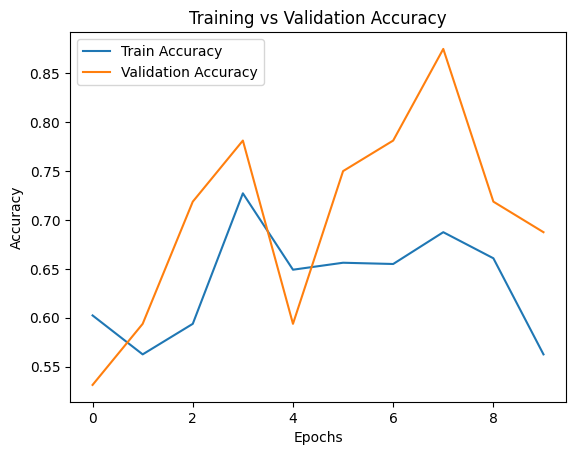

In [49]:
# ==============================
# 1 Import Libraries
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD


# ==============================
# 2 Parameters
# ==============================

img_size = 224
batch_size = 32
epochs = 10


# ==============================
# 3 Data Preprocessing + Augmentation
# ==============================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


# ==============================
# 4 CNN Model
# ==============================

model = models.Sequential()

# Block 1
model.add(layers.Conv2D(64,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 2
model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Block 3
model.add(layers.Conv2D(256,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.25))

# Flatten
model.add(layers.Flatten())

# Dense
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

# Output
model.add(layers.Dense(2,activation='softmax'))


# ==============================
# 5 Compile Model (SGD Optimizer)
# ==============================

optimizer = SGD(learning_rate=0.001,momentum=0.9)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# ==============================
# 6 Train Model
# ==============================

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)


# ==============================
# 7 Evaluate Model
# ==============================

loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:",accuracy)


# ==============================
# 8 Plot Training Graph
# ==============================

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()